### Assignment 11: Image Classification Using Random Forest
##### Name: Alyssa Iapalucci

This project uses the CIFAR-10 dataset to build and compare machine learning models for image classification.

Steps include data preprocessing, training a Random Forest model with GridSearchCV, evaluating performance, and comparing results with an SVM model.

The project also includes feature importance analysis and a simple prediction function for new images.

---

Github Link:

Google Colab Link: https://colab.research.google.com/drive/1bOlyhrBjk6xAbSWxD9jtOSVQs1wfVJOH?usp=sharing

---

In [ ]:
# STEP 1: IMPORT DATASET

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

In [ ]:
# STEP 1.1: LOAD DATASET

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [ ]:
# STEP 2: PREPROCESSING

# Combine dataset
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

print("Combined shape:", X.shape)

Combined shape: (60000, 32, 32, 3)


In [ ]:
# Resize step (CIFAR-10 already 32x32, so we confirm)
X_resized = X.copy()

In [ ]:
# Normalize
X_normalized = X_resized / 255.0

In [ ]:
# Flatten images
X_flattened = X_normalized.reshape(X_normalized.shape[0], -1)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_flattened,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (48000, 3072)
Test: (12000, 3072)


In [ ]:
# STEP 3: RANDOM FOREST + GRIDSEARCHCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

rf = RandomForestClassifier(random_state=42)

In [ ]:
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=2,
    n_jobs=-1,
    verbose=1
)

# SMALL SUBSET (prevents freezing)
grid_search.fit(X_train[:3000], y_train[:3000].ravel())

best_rf_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
# STEP 4: RANDOM FOREST EVALUATION

y_pred_rf = best_rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1:", f1_score(y_test, y_pred_rf, average='weighted'))

Accuracy: 0.36925
Precision: 0.3706138821670217
Recall: 0.36925
F1: 0.35844025630236986


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_rf)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.42      0.42      0.42      1181
           1       0.45      0.35      0.40      1188
           2       0.30      0.11      0.16      1232
           3       0.28      0.21      0.24      1274
           4       0.27      0.43      0.33      1179
           5       0.33      0.34      0.33      1230
           6       0.36      0.47      0.41      1123
           7       0.46      0.30      0.36      1217
           8       0.45      0.55      0.49      1189
           9       0.40      0.54      0.46      1187

    accuracy                           0.37     12000
   macro avg       0.37      0.37      0.36     12000
weighted avg       0.37      0.37      0.36     12000



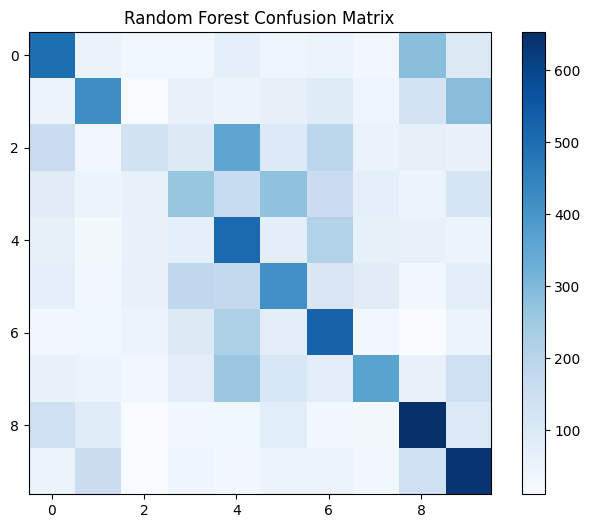

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
# STEP 5: FEATURE IMPORTANCE

importances = best_rf_model.feature_importances_
top_idx = np.argsort(importances)[-20:]

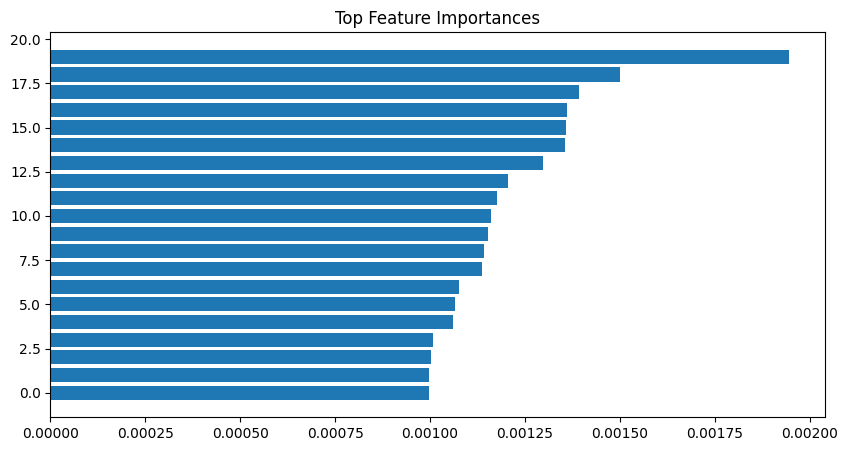

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.title("Top Feature Importances")
plt.show()

In [ ]:
# STEP 6: PREDICTION FUNCTION

def predict_image(model, image):
    image = image / 255.0
    image = image.reshape(1, -1)
    return model.predict(image)

print("Sample prediction:", predict_image(best_rf_model, X_test[0]))

Sample prediction: [3]


In [ ]:
# STEP 7: SVM COMPARISON

from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train[:3000], y_train[:3000].ravel())

SVC(kernel='linear')

In [ ]:
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.30433333333333334
